# Hand Gesture (10-class) — 2-Stage YOLOv8 + GRU for KV260원본 `KV260_RPS_Pretrained_YOLO_Finetuning_KV260.ipynb` 를 기반으로 가위바위보 대신17명 × 10제스처 × 30프레임 시퀀스 데이터셋을 학습하도록 개조.**왜 2단계인가**`left / right / up / down / hi / bye` 6개 클래스는 단일 프레임에서 서로 구분이 불가능하다.(모두 편 손이고 움직이는 방향만 다름 — 전체 960 시퀀스 중 594개, 62%)따라서 손 *모양*은 YOLO가, 손의 *움직임*은 GRU가 담당한다.| 단계 | 모델 | 입력 | 출력 | KV260 배치 ||---|---|---|---|---|| Stage 1 | YOLOv8s (SiLU→ReLU) | 프레임 1장 | bbox + 손모양 4클래스 | **DPU** || Stage 2 | GRU 2층 | 30프레임 시퀀스 | 제스처 10클래스 | **ARM Cortex-A53** |MediaPipe는 **오프라인 라벨 생성에만** 쓰고 보드에서는 실행하지 않는다.

## g-drive 마운트

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    print('g-drive mounted.')
    colab = True
except Exception:
    print('local drive.')
    colab = False

Mounted at /content/drive
g-drive mounted.


## 경로 및 하이퍼파라미터 설정

In [2]:
!df -h

Filesystem      Size  Used Avail Use% Mounted on
overlay         113G   47G   66G  42% /
tmpfs            64M     0   64M   0% /dev
shm             5.7G     0  5.7G   0% /dev/shm
/dev/root       2.0G  1.3G  696M  65% /usr/sbin/docker-init
tmpfs           6.4G   92K  6.4G   1% /var/colab
/dev/sda1       119G   52G   68G  44% /kaggle/input
tmpfs           6.4G     0  6.4G   0% /proc/acpi
tmpfs           6.4G     0  6.4G   0% /proc/scsi
tmpfs           6.4G     0  6.4G   0% /sys/firmware
drive           100G   41G   60G  41% /content/drive


In [3]:
# 다른 경로에 저장하려면, 아래 경로를 수정하세요
if colab:
    save_dir     = '/content/drive/MyDrive/ai/files/save/'
    raw_zip      = '/content/drive/MyDrive/ai/files/real_dataset.zip'  # 없으면 raw_root 직접 지정
    raw_root     = '/content/real_dataset'      # Subject N/<gesture>/<trial>/NNN.jpg
    dataset_root = '/content/Gesture_YOLO'      # Stage 1 학습용 (YOLO 포맷)
    seq_root     = '/content/Gesture_SEQ'       # Stage 2 학습용 (시퀀스 npz)
    project_root = '/content/gesture_runs'
else:
    save_dir     = '../files/save/'
    raw_zip      = '../files/real_dataset.zip'
    raw_root     = './real_dataset'
    dataset_root = './Gesture_YOLO'
    seq_root     = './Gesture_SEQ'
    project_root = './gesture_runs'

In [4]:
# ------------------------------------------------------------------
# 주요 하이퍼파라미터 (여기만 바꾸면 됨)
# ------------------------------------------------------------------
SEQ_LEN   = 30      # 데이터셋의 trial당 프레임 수 (전 trial 960개 모두 정확히 30)

# Stage 1 (YOLO)
STAGE1_IMGSZ  = 416   # 원본 RPS 노트북은 320. 이 데이터셋은 640x480 원거리 촬영이라
                      # 손이 40~60px에 불과 -> 320이면 손이 25px로 줄어 형태 구분이 어려움.
                      # KV260 fps가 부족하면 320으로 낮춰도 동작함 (GRU가 30프레임 누적 투표)
STAGE1_EPOCHS = 80
STAGE1_BATCH  = 32
# Stage1 프레임 샘플링 간격을 손 모양 클래스별로 다르게 준다 (불균형 보정).
# 폴더명 일괄 라벨링 시절 분포: open_palm 7320 / fist 960 / thumb_up 945 / thumb_down 1005 (7.6:1:1:1)
# 프레임 단위 라벨링 + open_palm stride 5 적용 시: 2893 / 1428 / 1772 / 1572 (2.0:1:1.2:1.1)
SHAPE_STRIDE = {'open_palm': 5, 'fist': 1, 'thumb_up': 1, 'thumb_down': 1}

# Stage 2 (GRU)
STAGE2_EPOCHS = 200
STAGE2_BATCH  = 16

# 피험자 단위 분할 (★중요: 무작위 분할 금지)
# 같은 trial의 30프레임은 거의 동일한 장면이라, 무작위로 나누면
# train/val에 같은 장면이 동시에 들어가 정확도가 크게 부풀려진다.
TRAIN_SUBJECTS = [f'Subject {i}' for i in range(1, 13)]   # 1~12  (681 seq)
VAL_SUBJECTS   = [f'Subject {i}' for i in range(13, 16)]  # 13~15 (159 seq)
TEST_SUBJECTS  = [f'Subject {i}' for i in range(16, 18)]  # 16~17 (116 seq)

## 원본 데이터셋 준비 및 구조 확인

In [5]:
import os, zipfile

if not os.path.isdir(raw_root) and os.path.exists(raw_zip):
    print('unzipping...')
    os.makedirs(os.path.dirname(raw_root) or '.', exist_ok=True)
    with zipfile.ZipFile(raw_zip) as z:
        z.extractall(os.path.dirname(raw_root) or '.')

assert os.path.isdir(raw_root), f'원본 데이터 폴더를 찾을 수 없습니다: {raw_root}'
print('raw_root =', raw_root)
print(sorted(os.listdir(raw_root))[:5], '...')

unzipping...
raw_root = /content/real_dataset
['Subject 1', 'Subject 10', 'Subject 11', 'Subject 12', 'Subject 13'] ...


In [6]:
import glob, collections

# 구조 검증: Subject N / gesture / trial / NNN.jpg
trials = sorted(glob.glob(os.path.join(raw_root, '*', '*', '*')))
trials = [t for t in trials if os.path.isdir(t)]

subs  = sorted({t.split(os.sep)[-3] for t in trials}, key=lambda s: int(s.split()[-1]))
gests = sorted({t.split(os.sep)[-2] for t in trials})
lens  = collections.Counter(len(glob.glob(os.path.join(t, '*.jpg'))) for t in trials)

print(f'피험자   : {len(subs)}명  {subs[:3]} ...')
print(f'제스처   : {len(gests)}개  {gests}')
print(f'시퀀스   : {len(trials)}개')
print(f'프레임/시퀀스 분포 : {dict(lens)}')
print(f'총 프레임 : {sum(k*v for k, v in lens.items())}')
assert set(lens) == {SEQ_LEN}, f'모든 trial이 {SEQ_LEN}프레임이어야 합니다: {dict(lens)}'

피험자   : 17명  ['Subject 1', 'Subject 2', 'Subject 3'] ...
제스처   : 10개  ['bye', 'close', 'down', 'hi', 'left', 'open', 'right', 'thumbs down', 'thumbs up', 'up']
시퀀스   : 960개
프레임/시퀀스 분포 : {30: 960}
총 프레임 : 28800


## 클래스 정의Stage 1(YOLO)은 **단일 프레임에서 실제로 구분 가능한 손 모양 4종**만 학습한다.10개 제스처를 그대로 YOLO에 넣으면 left/right/up/down/hi/bye가 서로 뒤섞인다.

In [7]:
# Stage 2: 최종 제스처 10클래스 (폴더명과 정확히 일치해야 함)
GESTURE_CLASSES = ['left', 'right', 'up', 'down', 'hi', 'bye',
                   'open', 'close', 'thumbs up', 'thumbs down']

# Stage 1: 단일 프레임에서 구분 가능한 손 모양 4클래스
SHAPE_CLASSES = ['open_palm', 'fist', 'thumb_up', 'thumb_down']

# 제스처 -> 손 모양 매핑
GESTURE2SHAPE = {
    'left':        'open_palm',
    'right':       'open_palm',
    'up':          'open_palm',
    'down':        'open_palm',
    'hi':          'open_palm',
    'bye':         'open_palm',
    'open':        'open_palm',
    'close':       'fist',
    'thumbs up':   'thumb_up',
    'thumbs down': 'thumb_down',
}

assert set(GESTURE2SHAPE) == set(GESTURE_CLASSES) == set(gests), \
    f'폴더명 불일치:\n  폴더={sorted(gests)}\n  정의={sorted(GESTURE_CLASSES)}'

G2I = {g: i for i, g in enumerate(GESTURE_CLASSES)}
S2I = {s: i for i, s in enumerate(SHAPE_CLASSES)}
print('OK — 폴더명과 클래스 정의가 일치합니다.')

OK — 폴더명과 클래스 정의가 일치합니다.


## 패키지 설치

In [8]:
!pip -q install -U ultralytics mediapipe

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.5/36.5 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 14.2 MB/s eta 0:00:00


## Stage 1 — MediaPipe 자동 라벨링

원본 RPS 데이터셋은 Pascal VOC XML 어노테이션이 있었으나, 이 데이터셋에는 바운딩박스가 전혀 없다.
따라서 MediaPipe로 21개 손 랜드마크를 검출하고, 그 min/max 좌표로 bbox를 생성한다.

**HandLandmarker 대신 GestureRecognizer를 쓰는 이유**

초기 버전은 폴더명 하나로 trial의 30프레임 전체에 동일한 손 모양 라벨을 찍었다.
그러나 `open`은 주먹에서 시작해 펼친 손으로 끝나고, `close`는 그 반대다.
즉 **동일한 펼친 손 이미지가 `open_palm`으로도 `fist`로도 라벨**되어 학습이 붕괴했고,
사전확률이 가장 높은 `open_palm`(전체의 71.6%)으로 전부 수렴하는 증상이 발생했다.

GestureRecognizer는 랜드마크와 함께 프레임별 손 모양 분류를 반환하므로,
전이 구간을 프레임 단위로 갈라낼 수 있다. 다만 판정을 전적으로 맡기지는 않고,
**폴더명이 주는 사전지식으로 후보를 좁힌 뒤 그 안에서만** MediaPipe가 결정하게 한다
(`ALLOWED_SHAPES`). 이동 계열 6개는 후보가 하나뿐이라 MediaPipe를 호출조차 하지 않으므로,
모션 블러가 심한 `left`/`down`에서 오판정이 발생할 여지가 없다.

**VIDEO 모드를 쓰는 이유**: trial 하나가 시간순 30프레임이므로, VIDEO 모드로 순서대로 넣으면
MediaPipe가 트래킹을 사용해 매 프레임 손바닥 검출을 다시 돌리지 않는다.
손이 작은(40~60px) 이 데이터셋에서는 검출률이 눈에 띄게 올라간다.

In [9]:
MP_MODEL = 'gesture_recognizer.task'   # 랜드마크 + 손모양 분류를 함께 반환
if not os.path.exists(MP_MODEL):
    !wget -q https://storage.googleapis.com/mediapipe-models/gesture_recognizer/gesture_recognizer/float16/1/gesture_recognizer.task -O {MP_MODEL}
print(MP_MODEL, os.path.exists(MP_MODEL), os.path.getsize(MP_MODEL), 'bytes')

gesture_recognizer.task True 8373440 bytes


In [10]:
import cv2, numpy as np, mediapipe as mp

BaseOptions              = mp.tasks.BaseOptions
GestureRecognizer        = mp.tasks.vision.GestureRecognizer
GestureRecognizerOptions = mp.tasks.vision.GestureRecognizerOptions
VisionRunningMode        = mp.tasks.vision.RunningMode

# 손이 작으므로 confidence 임계값을 낮게 잡는다
MP_OPTIONS = GestureRecognizerOptions(
    base_options=BaseOptions(model_asset_path=MP_MODEL),
    running_mode=VisionRunningMode.VIDEO,
    num_hands=1,
    min_hand_detection_confidence=0.3,
    min_hand_presence_confidence=0.3,
    min_tracking_confidence=0.3,
)

# MediaPipe canned gesture -> SHAPE_CLASSES
# 전체 카테고리: None / Closed_Fist / Open_Palm / Pointing_Up / Thumb_Down / Thumb_Up / Victory / ILoveYou
MP2SHAPE = {'Open_Palm': 'open_palm', 'Closed_Fist': 'fist',
            'Thumb_Up':  'thumb_up',  'Thumb_Down':  'thumb_down'}

# 폴더명이 주는 사전지식으로 후보를 좁힌다.
# 후보가 1개인 제스처는 MediaPipe 판정을 아예 쓰지 않으므로 블러 구간에서도 안전하다.
ALLOWED_SHAPES = {
    'left':  {'open_palm'}, 'right': {'open_palm'},
    'up':    {'open_palm'}, 'down':  {'open_palm'},
    'hi':    {'open_palm'}, 'bye':   {'open_palm'},
    'open':  {'open_palm', 'fist'},           # 주먹 -> 편 손
    'close': {'open_palm', 'fist'},           # 편 손 -> 주먹
    'thumbs up':   {'thumb_up',   'fist'},    # 팔 올리는 중 주먹으로 읽히는 구간 허용
    'thumbs down': {'thumb_down', 'fist'},
}
assert set(ALLOWED_SHAPES) == set(GESTURE_CLASSES), '제스처 목록 불일치'
assert all(s in SHAPE_CLASSES for v in ALLOWED_SHAPES.values() for s in v)

GESTURE_SCORE_MIN = 0.5   # 이 미만이면 판정 보류 -> Stage1 학습에서 제외

BBOX_MARGIN = 0.25   # 랜드마크 경계 대비 여유 (손등/손목 일부 포함)


def landmarks_to_bbox(lms, margin=BBOX_MARGIN):
    """21개 랜드마크 -> YOLO 정규화 bbox (cx, cy, w, h)"""
    xs = np.array([l.x for l in lms])
    ys = np.array([l.y for l in lms])
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    w, h = (x1 - x0), (y1 - y0)
    x0 -= w * margin; x1 += w * margin
    y0 -= h * margin; y1 += h * margin
    x0, y0 = max(0.0, x0), max(0.0, y0)
    x1, y1 = min(1.0, x1), min(1.0, y1)
    return ((x0 + x1) / 2, (y0 + y1) / 2, x1 - x0, y1 - y0)


def resolve_shape(gesture, res):
    """프레임 1장의 손 모양 결정. 확정 불가면 None -> Stage1 학습에서 제외.

    후보가 1개인 제스처(left/right/up/down/hi/bye)는 MediaPipe 판정을 쓰지 않는다.
    후보가 2개인 제스처(open/close/thumbs)만 프레임 단위로 갈라낸다."""
    allowed = ALLOWED_SHAPES[gesture]
    if len(allowed) == 1:
        return next(iter(allowed))
    if not res.gestures:
        return None
    top = res.gestures[0][0]
    if top.score < GESTURE_SCORE_MIN:
        return None
    s = MP2SHAPE.get(top.category_name)
    return s if s in allowed else None


def interpolate_missing(boxes):
    """검출 실패한 프레임(None)을 앞뒤 프레임에서 선형 보간.

    ★ Stage1 라벨 기록에는 더 이상 쓰지 않는다.
      손이 화면에 아예 없는 프레임(trial 시작부에 집중)에 보간 bbox를 찍으면
      '빈 배경 = 손'을 학습시키게 되어, 이전 버전에서 약 2,400프레임이 오염되어 있었다.
      Stage2 시퀀스는 cell 33이 YOLO 예측값으로 자체 보간하므로 영향이 없다."""
    n = len(boxes)
    idx = [i for i, b in enumerate(boxes) if b is not None]
    if not idx:
        return boxes, 0.0
    arr = np.array([boxes[i] for i in idx], dtype=np.float32)
    out = []
    for i in range(n):
        if boxes[i] is not None:
            out.append(boxes[i])
        else:
            out.append(tuple(np.interp(i, idx, arr[:, k]) for k in range(4)))
    return out, len(idx) / n

In [11]:
import shutil, random, csv
from tqdm.auto import tqdm

def label_trial(rec, trial_dir, ts0, gesture):
    """trial 폴더(30프레임)를 VIDEO 모드로 처리해 프레임별 (bbox, 손모양) 반환"""
    frames = sorted(glob.glob(os.path.join(trial_dir, '*.jpg')))
    boxes, shapes = [], []
    for k, fp in enumerate(frames):
        img = cv2.imread(fp)
        if img is None:
            boxes.append(None); shapes.append(None); continue
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB,
                          data=cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        res = rec.recognize_for_video(mp_img, ts0 + k * 33)
        if res.hand_landmarks:
            boxes.append(landmarks_to_bbox(res.hand_landmarks[0]))
            shapes.append(resolve_shape(gesture, res))
        else:
            boxes.append(None); shapes.append(None)
    return frames, boxes, shapes


def which_split(subject):
    if subject in TRAIN_SUBJECTS: return 'train'
    if subject in VAL_SUBJECTS:   return 'val'
    if subject in TEST_SUBJECTS:  return 'test'
    return None


# 출력 디렉터리 초기화
if os.path.isdir(dataset_root):
    shutil.rmtree(dataset_root)
for sp in ['train', 'val']:
    os.makedirs(f'{dataset_root}/images/{sp}', exist_ok=True)
    os.makedirs(f'{dataset_root}/labels/{sp}', exist_ok=True)
os.makedirs(seq_root, exist_ok=True)

meta, det_rates, ts = [], [], 0
shape_hist  = collections.Counter()   # 실제 기록된 라벨 분포
skip_reason = collections.Counter()   # nodet / ambig / stride
frame_log   = []                      # 프레임별 판정 기록 (검증용 CSV)

with GestureRecognizer.create_from_options(MP_OPTIONS) as rec:
    for trial_dir in tqdm(trials, desc='auto-labeling'):
        subject, gesture, trial = trial_dir.split(os.sep)[-3:]
        split = which_split(subject)
        if split is None:
            continue

        frames, boxes, shapes = label_trial(rec, trial_dir, ts, gesture)
        ts += (SEQ_LEN + 5) * 33          # trial 간 타임스탬프 단조 증가 보장

        rate = sum(b is not None for b in boxes) / len(boxes)
        det_rates.append(rate)
        frame_log += [(subject, gesture, trial, k,
                       shapes[k] or '-', int(boxes[k] is not None))
                      for k in range(len(frames))]

        # 검출률 20% 미만(6프레임 미만)은 신뢰 불가로 폐기.
        # ★ test split 에는 적용하지 않는다. MediaPipe 는 KV260 배포 파이프라인에 존재하지
        #   않는 도구이므로, 그것으로 테스트 세트를 거르면 '어려운 샘플만 제거'되어
        #   성능이 낙관적으로 측정된다.
        if rate < 0.2 and split != 'test':
            meta.append(dict(subject=subject, gesture=gesture, trial=trial,
                             split=split, rate=rate, used=False))
            continue

        tag = f"{subject.replace(' ', '')}_{gesture.replace(' ', '')}_{trial}"

        # Stage 1 학습셋에는 train/val만, 그리고 손 모양이 확정된 프레임만 기록
        if split in ('train', 'val'):
            for k, (fp, bb, sh) in enumerate(zip(frames, boxes, shapes)):
                if bb is None:                      # 손 미검출 -> 보간 bbox 쓰지 않고 제외
                    skip_reason['nodet'] += 1; continue
                if sh is None:                      # 손 모양 판정 불가 (전이 구간 등)
                    skip_reason['ambig'] += 1; continue
                if k % SHAPE_STRIDE[sh]:            # 클래스별 샘플링 (불균형 보정)
                    skip_reason['stride'] += 1; continue

                shape_id = S2I[sh]
                shape_hist[sh] += 1
                stem = f'{tag}_{k:03d}'
                dst = f'{dataset_root}/images/{split}/{stem}.jpg'
                try:
                    os.symlink(os.path.abspath(fp), dst)
                except (OSError, NotImplementedError):
                    shutil.copyfile(fp, dst)
                with open(f'{dataset_root}/labels/{split}/{stem}.txt', 'w') as f:
                    f.write(f"{shape_id} {' '.join(f'{v:.6f}' for v in bb)}\n")

        meta.append(dict(subject=subject, gesture=gesture, trial=trial,
                         split=split, rate=rate, used=True, dir=trial_dir))

det_rates = np.array(det_rates)
print(f'\nMediaPipe 검출률  평균 {det_rates.mean():.1%}  중앙값 {np.median(det_rates):.1%}')
print(f'  검출률 20% 미만으로 폐기된 시퀀스: {sum(1 for m in meta if not m["used"])}개')
print(f'\n기록된 라벨 분포: {dict(shape_hist)}')
if shape_hist:
    print(f'  최대/최소 비율: {max(shape_hist.values()) / min(shape_hist.values()):.2f}')
print(f'제외 사유: {dict(skip_reason)}')
for sp in ['train', 'val']:
    n = len(os.listdir(os.path.join(dataset_root, 'images', sp)))
    print(f'  Stage1 {sp}: {n} 프레임')

# 프레임별 판정 기록 저장 (전이 구간이 제대로 갈렸는지 사후 검증용)
csv_path = f'{seq_root}/frame_shapes.csv'
with open(csv_path, 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['subject', 'gesture', 'trial', 'frame', 'shape', 'detected'])
    w.writerows(frame_log)
print(f'\n프레임별 판정 기록 -> {csv_path}')

auto-labeling:   0%|          | 0/960 [00:00<?, ?it/s]


MediaPipe 검출률  평균 91.8%  중앙값 96.7%
  검출률 20% 미만으로 폐기된 시퀀스: 3개

기록된 라벨 분포: {'open_palm': 2892, 'fist': 1428, 'thumb_down': 1572, 'thumb_up': 1772}
  최대/최소 비율: 2.03
제외 사유: {'stride': 13054, 'nodet': 2091, 'ambig': 2421}
  Stage1 train: 6181 프레임
  Stage1 val: 1483 프레임

프레임별 판정 기록 -> /content/Gesture_SEQ/frame_shapes.csv


### data.yaml 생성

In [12]:
DATA = f'{dataset_root}/data.yaml'
with open(DATA, 'w') as f:
    f.write(f"path: {os.path.abspath(dataset_root)}\n")
    f.write("train: images/train\n")
    f.write("val: images/val\n")
    f.write(f"nc: {len(SHAPE_CLASSES)}\n")
    f.write(f"names: {SHAPE_CLASSES}\n")
print(open(DATA).read())

path: /content/Gesture_YOLO
train: images/train
val: images/val
nc: 4
names: ['open_palm', 'fist', 'thumb_up', 'thumb_down']



### 자동 라벨 육안 검증 (필수)

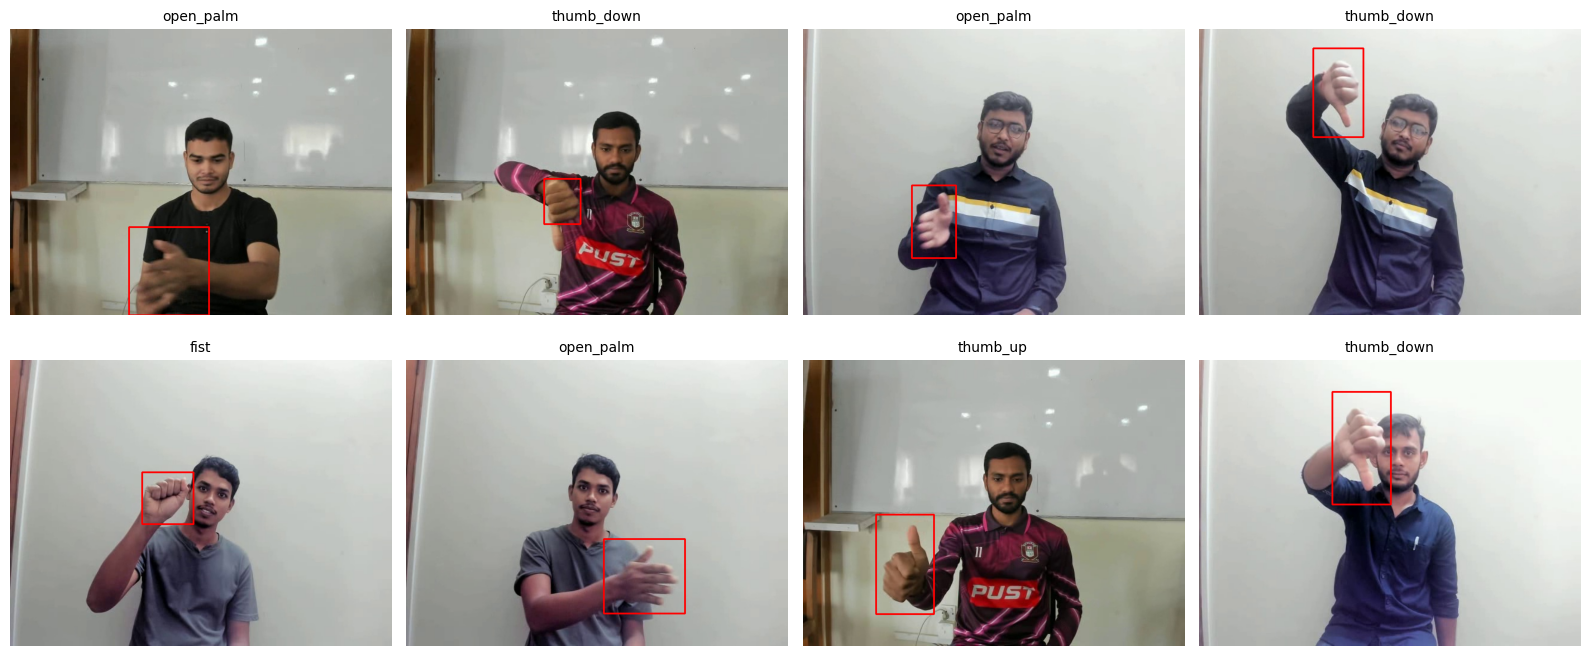

In [14]:
import matplotlib.pyplot as plt

samples = random.sample(sorted(glob.glob(f'{dataset_root}/images/train/*.jpg')), 8)
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, ip in zip(axes.ravel(), samples):
    img = cv2.cvtColor(cv2.imread(ip), cv2.COLOR_BGR2RGB)
    H, W = img.shape[:2]
    lp = ip.replace('/images/', '/labels/').replace('.jpg', '.txt')
    cid, cx, cy, w, h = open(lp).read().split()
    cx, cy, w, h = float(cx) * W, float(cy) * H, float(w) * W, float(h) * H
    cv2.rectangle(img, (int(cx - w / 2), int(cy - h / 2)),
                       (int(cx + w / 2), int(cy + h / 2)), (255, 0, 0), 2)
    ax.imshow(img); ax.set_title(SHAPE_CLASSES[int(cid)], fontsize=10); ax.axis('off')
plt.tight_layout(); plt.show()

## Ultralytics 및 DPU 호환 모듈

In [15]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import ultralytics.nn.modules.block as block

In [17]:
yolo = YOLO('yolov8s.pt')

In [18]:
# ------------------------------------------------------------------
# 1. DPU 호환 모듈 정의 (C2f -> DPUC3Block)
# ------------------------------------------------------------------
class DPUC3Block(nn.Module):
    def __init__(self, c2f_orig):
        super().__init__()
        if hasattr(c2f_orig, 'f'): self.f = c2f_orig.f
        if hasattr(c2f_orig, 'i'): self.i = c2f_orig.i

        c_in = c2f_orig.cv1.conv.in_channels
        c_out = c2f_orig.cv2.conv.out_channels
        c_hidden = c2f_orig.c

        self.cv1 = nn.Sequential(
            nn.Conv2d(c_in, c_hidden, 1, 1, bias=False),
            nn.BatchNorm2d(c_hidden),
            nn.ReLU(inplace=False)
        )
        self.cv2 = nn.Sequential(
            nn.Conv2d(c_in, c_hidden, 1, 1, bias=False),
            nn.BatchNorm2d(c_hidden),
            nn.ReLU(inplace=False)
        )
        self.m = nn.Sequential(*c2f_orig.m)
        self.cv3 = nn.Sequential(
            nn.Conv2d(c_hidden * 2, c_out, 1, 1, bias=False),
            nn.BatchNorm2d(c_out),
            nn.ReLU(inplace=False)
        )

    def forward(self, x):
        out1 = self.m(self.cv1(x))
        out2 = self.cv2(x)
        return self.cv3(torch.cat((out1, out2), dim=1))

def replace_c2f_with_dpu_c3(model):
    for name, child in model.named_children():
        if isinstance(child, block.C2f):
            setattr(model, name, DPUC3Block(child))
        else:
            replace_c2f_with_dpu_c3(child)

# ------------------------------------------------------------------
# 2. DPU 호환 모듈 정의 (SiLU -> ReLU)
# ------------------------------------------------------------------
def replace_silu_with_relu(module):
    for name, child in module.named_children():
        if isinstance(child, torch.nn.SiLU):
            setattr(module, name, torch.nn.ReLU(inplace=False))
        else:
            replace_silu_with_relu(child)

# ------------------------------------------------------------------
# 3. DPU 호환 모듈 정의 (SiLU -> Leaky ReLU)
# ------------------------------------------------------------------
# negative_slope 는 26/256 = 0.1015625.
# DPUCZDX8G 는 LeakyReLU 계수가 0.1 로 고정되어 있고, 26/256 이 그 고정소수점 표현이다.
# 0.08 같은 임의값을 쓰면 컴파일러가 해당 레이어를 CPU 로 떨어뜨린다.
# 사용하려면 Vivado 에서 DPU IP 의 ReLU Type 을 RELU_LEAKYRELU_RELU6 로 설정해야 한다.
DPU_LEAKY_SLOPE = 26 / 256

def replace_silu_with_leaky_relu(module):
    for name, child in module.named_children():
        if isinstance(child, torch.nn.SiLU):
            setattr(module, name,
                    torch.nn.LeakyReLU(negative_slope=DPU_LEAKY_SLOPE, inplace=False))
        else:
            replace_silu_with_leaky_relu(child)   # (수정) 자기 자신을 재귀 호출

In [19]:
# ------------------------------------------------------------------
# SiLU -> ReLU 교체 (DPUCZDX8G 는 SiLU 를 지원하지 않는다)
# ------------------------------------------------------------------
# ★ 모듈을 직접 갈아끼우는 것만으로는 학습에 반영되지 않는다.
#   yolo.train() 은 model.yaml 로 DetectionModel 을 새로 생성한 뒤 state_dict 만 옮긴다
#   (ultralytics/engine/model.py: trainer.get_model(weights=..., cfg=self.model.yaml)).
#   활성함수는 학습 파라미터가 없어 state_dict 에 존재하지 않으므로,
#   교체는 조용히 무효화되고 yaml 기준값(SiLU)으로 되돌아간다.
#   parse_model 이 yaml['activation'] 을 읽어 Conv.default_act 를 세팅하므로 그쪽을 고친다.
yolo.model.yaml['activation'] = 'nn.ReLU()'
replace_silu_with_relu(yolo.model)          # 학습 전 즉시 추론/디버깅용

# replace_c2f_with_dpu_c3(yolo.model)
#   ↑ 켜지 말 것.
#     (1) yaml 로 표현할 수 없어 train() 이 재생성할 때 C2f 로 되돌아간다
#     (2) cv1/cv2/cv3 가 랜덤 초기화되어 사전학습 가중치를 버린다
#     (3) best.pt 는 모델 객체를 피클하므로, 클래스 정의가 없는 세션에서
#         YOLO(BEST) 호출 시 AttributeError 가 난다
#     C2f 자체는 conv/concat/add 로만 구성되어 DPU 가 지원한다. 병목은 SiLU 였다.

# replace_silu_with_leaky_relu(yolo.model)
#   ↑ 쓰려면 Vivado 에서 DPU IP 의 ReLU Type 을 RELU_LEAKYRELU_RELU6 로 설정해야 한다.

n_silu = sum(isinstance(m, torch.nn.SiLU) for m in yolo.model.modules())
n_relu = sum(isinstance(m, torch.nn.ReLU) for m in yolo.model.modules())
print(f"학습 전  SiLU {n_silu} / ReLU {n_relu}")
print(f"yaml activation = {yolo.model.yaml.get('activation')}")

학습 전  SiLU 0 / ReLU 57
yaml activation = nn.ReLU()


## Stage 1 학습원본 RPS 노트북 대비 증강 파라미터 변경:- `fliplr=0.0` — 좌우반전 시 `left` 시퀀스가 `right`가 되어 **라벨이 오염**된다 (RPS는 가위를 뒤집어도 가위라 무해했음)- `flipud=0.0` — 상하반전 시 `thumbs up` <-> `thumbs down` 이 뒤바뀐다- `degrees=15 -> 8`, `scale=0.2 -> 0.3` — 회전은 엄지 방향을 흐리므로 축소, 대신 손 크기 변화에 대비해 scale 확대

In [20]:
!rm -rf {project_root}

In [21]:
yolo.train(data=DATA, epochs=STAGE1_EPOCHS, batch=STAGE1_BATCH,
           imgsz=STAGE1_IMGSZ,
           device=0 if torch.cuda.is_available() else 'cpu',
           workers=4,
           project=project_root,
           degrees=8.0,
           flipud=0.0,      # ★ thumbs up <-> thumbs down 라벨 오염 방지
           fliplr=0.0,      # ★ left <-> right 라벨 오염 방지
           mosaic=1.0,
           scale=0.3,
           translate=0.1,
           hsv_h=0.015,
           hsv_s=0.7,
           hsv_v=0.4,
           name='gesture_stage1')

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Gesture_YOLO/data.yaml, degrees=8.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=gesture_stage1, nbs=64, nms=F

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f6fa8044b90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [22]:
BEST = f'{project_root}/gesture_stage1/weights/best.pt'
print(BEST, os.path.exists(BEST))

# ★ 학습된 체크포인트에 SiLU 가 남아있지 않은지 확인한다.
#   남아있으면 vai_c_xir 단계에서 해당 연산이 CPU 서브그래프로 분리되어
#   DPU 그래프가 잘게 쪼개지고 fps 가 급락한다.
_chk = YOLO(BEST).model
_silu = sum(isinstance(m, torch.nn.SiLU) for m in _chk.modules())
_relu = sum(isinstance(m, torch.nn.ReLU) for m in _chk.modules())
print(f'학습 후  SiLU {_silu} / ReLU {_relu}')
assert _silu == 0, 'SiLU 가 남아있다 — cell 27 의 yaml activation 설정을 확인할 것'
del _chk

/content/gesture_runs/gesture_stage1/weights/best.pt True
학습 후  SiLU 0 / ReLU 1


## Stage 2 — 시퀀스 특징 추출

학습된 Stage 1 모델로 960개 trial 전체(폐기분 제외)를 프레임 단위 추론하여
GRU 입력 시퀀스를 만든다.

**프레임당 11차원 특징**

| 차원 | 내용 | 역할 |
|---|---|---|
| 0~1 | bbox 중심 `cx, cy` | left/right/up/down 판별 |
| 2~3 | bbox 크기 `w, h` | 손이 다가오는지 |
| 4 | `confidence` | 0이면 미검출(보간된 프레임) 표식 |
| 5~8 | 손모양 one-hot 4종 | open/close/thumbs up/down 판별 |
| 9~10 | `dcx, dcy` (속도) | hi/bye 진동 판별 |

MediaPipe가 아니라 **YOLO 출력만** 사용한다는 점이 핵심이다.
보드 위에서는 DPU가 이 값을 그대로 내주므로 MediaPipe가 필요 없다.

**★ 알려진 한계 — 특징 추출과 Stage 1 학습의 피험자 중복**

여기서 쓰는 `det = YOLO(BEST)` 는 Subject 1~15 의 프레임으로 학습된 모델이다.
그런데 아래 셀은 train/val/test 전체에 대해 특징을 뽑는다.
따라서 train/val 시퀀스는 **자기 자신을 학습한 검출기가 만든 낙관적인 특징**이고,
test 시퀀스(Subject 16~17)만 실제 배포 조건의 노이즈를 담는다.

이 분포 차이는 val 정확도와 test 정확도의 격차에 직접 기여한다.
엄밀하게는 Stage 1 을 피험자 k-fold 로 여러 번 학습하여 각 fold 의 hold-out
피험자에 대해서만 특징을 뽑아야 하지만, 학습 비용이 k 배가 되므로
본 실습에서는 적용하지 않고 한계로 명시한다.
따라서 **val 정확도는 낙관 편향이 있으며, test 정확도만 배포 성능의 추정치로 본다.**

In [23]:
FEAT_DIM = 11
det = YOLO(BEST)

def trial_to_sequence(trial_dir):
    """trial 폴더 -> (SEQ_LEN, FEAT_DIM) 특징 시퀀스"""
    frames = sorted(glob.glob(os.path.join(trial_dir, '*.jpg')))
    seq = np.zeros((SEQ_LEN, FEAT_DIM), dtype=np.float32)
    raw = []

    results = det.predict(frames, imgsz=STAGE1_IMGSZ, conf=0.15, verbose=False)
    for r in results[:SEQ_LEN]:
        if r.boxes is None or len(r.boxes) == 0:
            raw.append(None); continue
        b = int(r.boxes.conf.argmax())
        cx, cy, w, h = r.boxes.xywhn[b].tolist()
        raw.append((cx, cy, w, h, float(r.boxes.conf[b]), int(r.boxes.cls[b])))

    idx = [i for i, v in enumerate(raw) if v is not None]
    if not idx:
        return None                          # 전 프레임 미검출 -> 시퀀스 폐기

    arr = np.array([raw[i][:4] for i in idx], dtype=np.float32)
    for i in range(SEQ_LEN):
        if raw[i] is not None:
            cx, cy, w, h, conf, cls = raw[i]
        else:
            cx, cy, w, h = (float(np.interp(i, idx, arr[:, k])) for k in range(4))
            conf = 0.0                       # ★ '보간된 프레임' 표식
            cls  = raw[min(idx, key=lambda j: abs(j - i))][5]   # 최근접 검출의 클래스
        seq[i, 0:4] = (cx, cy, w, h)
        seq[i, 4]   = conf
        seq[i, 5 + cls] = 1.0

    # 속도 성분 (위에서 보간을 마쳤으므로 전 구간에서 계산 가능)
    seq[1:,  9] = seq[1:, 0] - seq[:-1, 0]     # 보간 후엔 전 구간 계산 가능
    seq[1:, 10] = seq[1:, 1] - seq[:-1, 1]
    return seq

In [24]:
used = [m for m in meta if m['used']]

Xs, ys, groups, dropped = [], [], [], 0
for m in tqdm(used, desc='sequence extraction'):
    s = trial_to_sequence(m['dir'])
    if s is None:
        dropped += 1; continue
    Xs.append(s); ys.append(G2I[m['gesture']]); groups.append(m['split'])
X, y, groups = np.stack(Xs), np.array(ys), np.array(groups)
print(f'YOLO 전 프레임 미검출로 폐기: {dropped}개')

# 손 모양 one-hot(5~8) 이 모든 타임스텝에서 정확히 하나 세워져 있어야 한다.
# (기존 assert 는 11차원 전체 합이 0인지 보았는데, one-hot 이 항상 1을 넣으므로
#  어떤 입력에도 통과하는 무의미한 검사였다.)
assert (X[:, :, 5:9].sum(axis=2) == 1).all(), '손 모양 one-hot 이 비어있는 타임스텝이 있음'

np.savez_compressed(f'{seq_root}/sequences.npz', X=X, y=y, groups=groups)

Xtr, ytr = X[groups == 'train'], y[groups == 'train']
Xva, yva = X[groups == 'val'],   y[groups == 'val']
Xte, yte = X[groups == 'test'],  y[groups == 'test']
print(f'train {Xtr.shape}   val {Xva.shape}   test {Xte.shape}')
print('클래스 분포(train):', dict(zip(GESTURE_CLASSES, np.bincount(ytr, minlength=10))))

sequence extraction:   0%|          | 0/957 [00:00<?, ?it/s]

YOLO 전 프레임 미검출로 폐기: 0개
train (682, 30, 11)   val (159, 30, 11)   test (116, 30, 11)
클래스 분포(train): {'left': np.int64(64), 'right': np.int64(70), 'up': np.int64(72), 'down': np.int64(68), 'hi': np.int64(69), 'bye': np.int64(78), 'open': np.int64(67), 'close': np.int64(64), 'thumbs up': np.int64(63), 'thumbs down': np.int64(67)}


### 시퀀스 증강train 시퀀스가 700개 내외로 적다. 좌표에 노이즈/평행이동/시간축 워핑을 주어 늘린다.**좌우·상하 반전은 절대 금지** — 라벨이 뒤바뀐다.

In [25]:
def augment_batch(X, y, n_copies=4, seed=0):
    rng = np.random.default_rng(seed)
    Xs, ys = [X], [y]
    for _ in range(n_copies):
        A = X.copy()
        # 보간 적용 후에는 전 프레임의 좌표가 유효하므로 det_mask 불필요

        shift = rng.normal(0, 0.02, (len(A), 1, 2))      # 사람 위치 차이
        A[..., 0:2] += shift

        sc = rng.normal(1.0, 0.08, (len(A), 1, 1))       # 카메라 거리 차이
        A[..., 2:4] *= sc

        A[..., 0:4] += rng.normal(0, 0.005, A[..., 0:4].shape)   # 검출 지터

        # 시간축 워핑 (속도 차이)
        for i in range(len(A)):
            src = np.clip(np.arange(SEQ_LEN) + rng.normal(0, 1.2, SEQ_LEN), 0, SEQ_LEN - 1)
            A[i] = A[i][np.round(np.sort(src)).astype(int)]

        A[..., 0:4] = np.clip(A[..., 0:4], 0, 1)

        # 속도 성분 재계산 (워핑·시프트로 좌표가 바뀌었으므로)
        A[:, 1:,  9] = A[:, 1:, 0] - A[:, :-1, 0]
        A[:, 1:, 10] = A[:, 1:, 1] - A[:, :-1, 1]
        A[:, 0, 9:11] = 0

        Xs.append(A.astype(np.float32)); ys.append(y)
    return np.concatenate(Xs), np.concatenate(ys)

Xtr_a, ytr_a = augment_batch(Xtr, ytr, n_copies=4)
print('증강 후 train:', Xtr_a.shape)

증강 후 train: (3410, 30, 11)


### GRU 모델LSTM 대신 GRU를 쓰는 이유: 시퀀스가 30프레임으로 짧고 학습 데이터가 700개 수준이라파라미터가 적은 GRU가 과적합에 강하다. 또한 KV260의 ARM Cortex-A53에서 실행되므로연산량이 적을수록 좋다 (이 모델은 5만 파라미터 미만).

In [26]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_gru(seq_len=SEQ_LEN, feat=FEAT_DIM, n_cls=len(GESTURE_CLASSES)):
    m = models.Sequential([
        layers.Input(shape=(seq_len, feat)),
        layers.GRU(64, return_sequences=True),
        layers.Dropout(0.3),
        layers.GRU(32),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(n_cls, activation='softmax'),
    ])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

gru = build_gru()
gru.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 30, 64)         │        14,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,578 (99.91 KB)

 Trainable params: 25,578 (99.91 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
hist = gru.fit(
    Xtr_a, ytr_a,
    validation_data=(Xva, yva),
    epochs=STAGE2_EPOCHS,
    batch_size=STAGE2_BATCH,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=30,
                                         restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=12),
    ],
    verbose=2,
)

Epoch 1/200
214/214 - 7s - 31ms/step - accuracy: 0.5038 - loss: 1.3661 - val_accuracy: 0.6101 - val_loss: 1.1873 - learning_rate: 0.0010
Epoch 2/200
214/214 - 2s - 8ms/step - accuracy: 0.7815 - loss: 0.5196 - val_accuracy: 0.6981 - val_loss: 0.7010 - learning_rate: 0.0010
Epoch 3/200
214/214 - 2s - 10ms/step - accuracy: 0.8188 - loss: 0.4078 - val_accuracy: 0.7044 - val_loss: 0.7901 - learning_rate: 0.0010
Epoch 4/200
214/214 - 3s - 12ms/step - accuracy: 0.8446 - loss: 0.3336 - val_accuracy: 0.6667 - val_loss: 1.0830 - learning_rate: 0.0010
Epoch 5/200
214/214 - 2s - 8ms/step - accuracy: 0.8666 - loss: 0.2875 - val_accuracy: 0.7547 - val_loss: 0.8066 - learning_rate: 0.0010
Epoch 6/200
214/214 - 2s - 8ms/step - accuracy: 0.8721 - loss: 0.2639 - val_accuracy: 0.7925 - val_loss: 0.7498 - learning_rate: 0.0010
Epoch 7/200
214/214 - 2s - 8ms/step - accuracy: 0.8848 - loss: 0.2432 - val_accuracy: 0.8239 - val_loss: 0.6253 - learning_rate: 0.0010
Epoch 8/200
214/214 - 2s - 8ms/step - accurac

## 평가`hi` vs `bye`, `left` vs `right`, `open` vs 나머지 open_palm 계열의 혼동을 중점적으로 확인한다.논문에서도 `open`이 91.5%로 가장 낮았고 left/right/bye와 혼동되었다.

              precision    recall  f1-score   support

        left      0.929     0.929     0.929        14
       right      0.750     1.000     0.857         9
          up      1.000     0.909     0.952        11
        down      0.929     1.000     0.963        13
          hi      1.000     0.917     0.957        12
         bye      1.000     1.000     1.000        14
        open      0.833     0.833     0.833        12
       close      1.000     0.818     0.900        11
   thumbs up      0.900     0.900     0.900        10
 thumbs down      1.000     1.000     1.000        10

    accuracy                          0.931       116
   macro avg      0.934     0.931     0.929       116
weighted avg      0.938     0.931     0.932       116



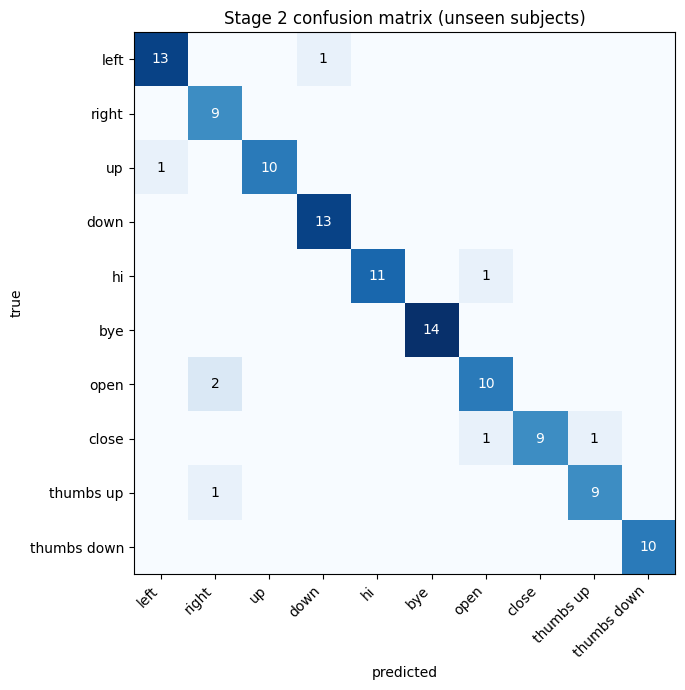

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

pred = gru.predict(Xte, verbose=0).argmax(1)
print(classification_report(yte, pred, target_names=GESTURE_CLASSES, digits=3, zero_division=0))

cm = confusion_matrix(yte, pred, labels=range(len(GESTURE_CLASSES)))
fig, ax = plt.subplots(figsize=(8, 7))
ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(10)); ax.set_xticklabels(GESTURE_CLASSES, rotation=45, ha='right')
ax.set_yticks(range(10)); ax.set_yticklabels(GESTURE_CLASSES)
ax.set_xlabel('predicted'); ax.set_ylabel('true')
for i in range(10):
    for j in range(10):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.title('Stage 2 confusion matrix (unseen subjects)')
plt.tight_layout(); plt.show()

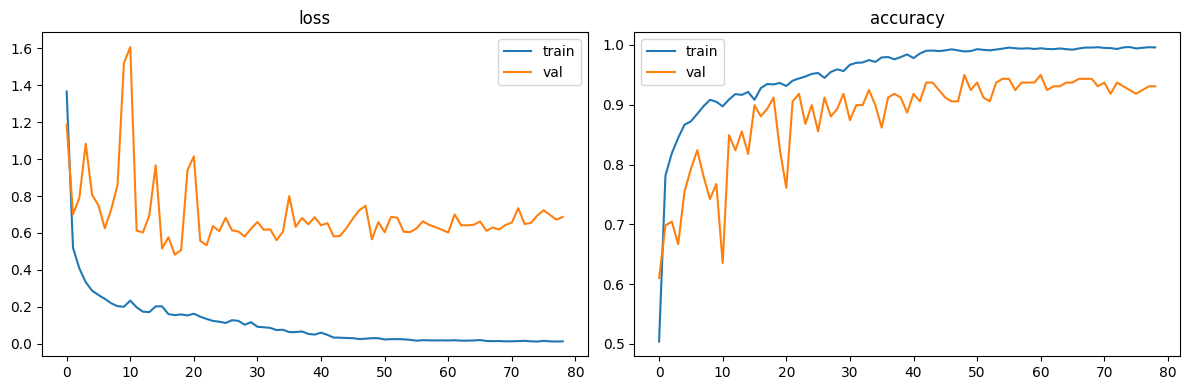

In [29]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist.history['loss'], label='train'); ax[0].plot(hist.history['val_loss'], label='val')
ax[0].set_title('loss'); ax[0].legend()
ax[1].plot(hist.history['accuracy'], label='train'); ax[1].plot(hist.history['val_accuracy'], label='val')
ax[1].set_title('accuracy'); ax[1].legend()
plt.tight_layout(); plt.show()

## 내보내기- `best_gesture_stage1.pt` — Vitis-AI 양자화 → DPU 컴파일 대상- `gesture_stage2_gru.tflite` — KV260 ARM 코어에서 실행 (TFLite runtime)

In [30]:
# ── Stage 2 내보내기 ──────────────────────────────────────────────
# 학습된 모델은 GPU에서 cuDNN 커널로 그래프가 굳어 TFLite 변환이 불가능하다.
# 따라서 동일 구조를 CPU에서 unroll 형태로 재구성하고 가중치만 이식한다.
# unroll=True 는 30스텝을 정적으로 펼쳐 WHILE/TensorList 연산을 제거하므로,
# ARM에서 Flex delegate 없이 기본 TFLite 런타임만으로 실행된다.

gru.save('gesture_stage2_gru.keras')          # 원본은 그대로 보관

def build_gru_export():
    m = models.Sequential([
        layers.Input(shape=(SEQ_LEN, FEAT_DIM)),
        layers.GRU(64, return_sequences=True, use_cudnn=False, unroll=True),
        layers.Dropout(0.3),
        layers.GRU(32, use_cudnn=False, unroll=True),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dense(len(GESTURE_CLASSES), activation='softmax'),
    ])
    return m

with tf.device('/CPU:0'):
    exp = build_gru_export()
    exp.set_weights(gru.get_weights())        # 구조가 같으므로 그대로 이식

    conv = tf.lite.TFLiteConverter.from_keras_model(exp)
    conv.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]   # Flex 불필요
    tflite = conv.convert()

open('gesture_stage2_gru.tflite', 'wb').write(tflite)
print(f'tflite size: {len(tflite)/1024:.1f} KB')

# ── 변환 정확도 검증 (필수) ────────────────────────────────────────
itp = tf.lite.Interpreter(model_content=tflite)
itp.allocate_tensors()
i0, o0 = itp.get_input_details()[0], itp.get_output_details()[0]
itp.resize_tensor_input(i0['index'], [1, SEQ_LEN, FEAT_DIM])
itp.allocate_tensors()

n = min(50, len(Xte))
diffs, agree = [], 0
for k in range(n):
    x = Xte[k:k+1].astype(np.float32)
    itp.set_tensor(i0['index'], x); itp.invoke()
    t_out = itp.get_tensor(o0['index'])[0]
    k_out = gru.predict(x, verbose=0)[0]
    diffs.append(np.abs(t_out - k_out).max())
    agree += int(t_out.argmax() == k_out.argmax())

print(f'Keras vs TFLite  최대오차 {max(diffs):.2e}   예측일치 {agree}/{n}')
assert agree == n, 'TFLite 변환 후 예측이 달라짐 — 배포 전 원인 파악 필요'
print('사용 연산:', sorted({d["op_name"] for d in itp._get_ops_details()}))

Saved artifact at '/tmp/tmp_bg6k3mp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 11), dtype=tf.float32, name='keras_tensor_7')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  140117341223632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140117341221904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140117341219408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140117341222864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140117341224592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140117341217872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140117341220752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140117341218832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140117341224784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140117341224016: TensorSpec(shape=(), dtype=tf.resource, name=None)
tflite size: 299.5

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Keras vs TFLite  최대오차 4.17e-07   예측일치 50/50
사용 연산: ['ADD', 'DELEGATE', 'FILL', 'FULLY_CONNECTED', 'LOGISTIC', 'MUL', 'PACK', 'SHAPE', 'SOFTMAX', 'SPLIT', 'STRIDED_SLICE', 'SUB', 'TANH', 'TRANSPOSE', 'UNPACK']


In [34]:
# ── DPU 양자화 전처리 ────────────────────────────────────────────
def unshare_activations(module):
    """parse_model 은 Conv.default_act 인스턴스 하나를 전체 Conv 가 공유하게 만든다.
    양자화기가 모듈 단위로 캘리브레이션 통계를 모을 경우 재사용된 인스턴스에서
    통계가 덮어써질 수 있으므로 각 모듈에 독립 인스턴스를 준다."""
    for name, child in module.named_children():
        if isinstance(child, torch.nn.ReLU):
            setattr(module, name, torch.nn.ReLU(inplace=False))
        else:
            unshare_activations(child)

dpu_model = YOLO(BEST).model.float().eval()
unshare_activations(dpu_model)

# 검사할 것은 개수가 아니라 '공유가 남아있지 않은가' 이다.
# Identity / Sigmoid 를 act 로 갖는 모듈도 있으므로 ReLU 소유자만 센다.
owners = [m for m in dpu_model.modules()
          if isinstance(getattr(m, 'act', None), torch.nn.ReLU)]
distinct = len({id(m.act) for m in owners})
print(f'ReLU 소유 모듈 {len(owners)} / 서로 다른 인스턴스 {distinct}')
assert distinct == len(owners), '공유된 ReLU 인스턴스가 남아있다'

assert sum(isinstance(m, torch.nn.SiLU) for m in dpu_model.modules()) == 0

# 참고: ReLU 가 아닌 활성함수를 가진 모듈 확인 (Identity/Sigmoid 는 정상)
for m in dpu_model.modules():
    a = getattr(m, 'act', None)
    if a is not None and not isinstance(a, torch.nn.ReLU):
        print(f'  {type(m).__name__}.act = {type(a).__name__}')

# vai_q_pytorch 전제조건: float 모델이 jit trace 를 통과해야 한다
try:
    with torch.no_grad():
        torch.jit.trace(dpu_model,
                        torch.randn(1, 3, STAGE1_IMGSZ, STAGE1_IMGSZ),
                        strict=False)
    print('torch.jit.trace 통과')
except Exception as e:
    print('torch.jit.trace 실패 — Detect 헤드가 원인이면 '
          'dpu_model.model[-1].export = True 로 두고 재시도:', repr(e)[:200])

torch.save(dpu_model, 'best_gesture_stage1_dpu.pt')
print('저장 완료: best_gesture_stage1_dpu.pt')

ReLU 소유 모듈 56 / 서로 다른 인스턴스 56
  Conv.act = Identity
torch.jit.trace 실패 — Detect 헤드가 원인이면 dpu_model.model[-1].export = True 로 두고 재시도: RuntimeError("Tracer cannot infer type of (tensor([[[6.4151e+00, 1.0045e+01, 1.5163e+01,  ..., 3.7972e+02, 4.0722e+02, 4.0693e+02],\n         [1.8134e+01, 1.7646e+01, 9.9785e+00,  ..., 4.4799e+02, 4.9
저장 완료: best_gesture_stage1_dpu.pt


In [31]:
import subprocess, shutil as _sh

_sh.copy(BEST, 'best_gesture_stage1.pt')
for _f in ['sequences.npz', 'frame_shapes.csv']:
    if os.path.exists(f'{seq_root}/{_f}'):
        _sh.copy(f'{seq_root}/{_f}', _f)

# 절대경로를 그대로 tar 에 넘기면 'Removing leading /' 경고가 나므로 -C 로 상대화한다.
_parent = os.path.dirname(os.path.abspath(project_root))
_name   = os.path.basename(os.path.abspath(project_root))
_files  = ['best_gesture_stage1.pt', 'gesture_stage2_gru.keras',
           'gesture_stage2_gru.tflite', 'sequences.npz', 'frame_shapes.csv']
_files  = [f for f in _files if os.path.exists(f)]

subprocess.run(['tar', '-czf', 'gesture_kv260.tar.gz',
                '-C', _parent, _name,
                '-C', os.getcwd(), *_files], check=True)
print('아카이브 포함:', _name, _files)

아카이브 포함: gesture_runs ['best_gesture_stage1.pt', 'gesture_stage2_gru.keras', 'gesture_stage2_gru.tflite', 'sequences.npz', 'frame_shapes.csv']


In [32]:
if colab:
    from google.colab import files
    files.download('gesture_kv260.tar.gz')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## KV260 배치 시 참고

**Stage 1 (DPU)**

```bash
vai_q_pytorch  ...  best_gesture_stage1.pt      # 양자화
vai_c_xir      ...  --arch /opt/vitis_ai/compiler/arch/DPUCZDX8G/KV260/arch.json
```

활성함수는 cell 27 에서 `yolo.model.yaml['activation'] = 'nn.ReLU()'` 로 지정했고,
cell 31 의 assert 로 학습된 체크포인트에 SiLU 가 0개임을 확인했다.
따라서 SiLU 미지원 문제는 발생하지 않는다.

> 주의: `replace_silu_with_relu()` 를 호출하는 것만으로는 부족하다.
> `yolo.train()` 이 model.yaml 로 모델을 재생성하면서 활성함수를 되돌리기 때문이다.
> 반드시 yaml 쪽을 고치고 cell 31 의 검증을 통과시킬 것.

컴파일 로그에 CPU 로 떨어지는 레이어가 남더라도 `replace_c2f_with_dpu_c3()` 는
켜지 말 것 (사유는 cell 27 주석 참조). C2f 는 conv/concat/add 로만 구성되어
DPU 가 지원하는 연산이다.

**Stage 2 (ARM)**

`gesture_stage2_gru.tflite` 를 30프레임 슬라이딩 윈도우로 실행한다.
매 프레임 DPU 출력 11차원을 링버퍼에 넣고, 버퍼가 차면 GRU 를 1회 호출한다.
파라미터가 2.6만 개라 Cortex-A53 에서 1ms 미만으로 끝난다.

**성능이 기대에 못 미칠 때**

| 증상 | 원인 | 대응 |
|---|---|---|
| MediaPipe 검출률 저조 | 손이 40~60px 로 작음 | `min_hand_detection_confidence` / `min_hand_presence_confidence` 하향 (`BBOX_MARGIN` 은 검출 후 박스를 넓히는 값이라 검출률과 무관하다) |
| `close` recall 저조 | Stage 1 이 전이 구간을 잘못 라벨 | cell 17 의 `frame_shapes.csv` 에서 open/close 의 프레임별 판정 분포를 확인 |
| thumbs up/down 혼동 | `STAGE1_IMGSZ` 부족 | 416 → 512 (fps 와 교환) |
| hi ↔ bye 혼동 | 두 동작 모두 머리 옆 흔들기 | 논문에서도 hi 가 95.2%로 최저. 두 클래스 통합 검토 |
| open ↔ left/right/bye 혼동 | open 은 정지, 나머지는 이동 | 속도 특징(9~10차원) 가중치 확대 또는 `dcx` 누적합 추가 |
| val 정확도만 높고 test 는 낮음 | 피험자 과적합 + **cell 32 에 명시한 특징 추출 편향** | `TRAIN_SUBJECTS` 확대, 증강 `n_copies` 상향. 구조적 해결은 Stage 1 의 피험자 k-fold |